# Shape Functions — what an SGT node actually does

A classic decision-tree node asks one yes/no question (`x < t`). A **Shape Generalized Tree** node is richer: it runs a small *inner tree* over one feature, carving that feature into several bins, then routes each bin to a child. That inner tree **is** the node's shape function. This notebook shows how the shape-function knobs change what a single node can express.

## The knobs

- `inner_max_depth` — depth of the inner tree. `1` = a single threshold (plain CART); higher = more bins, more non-linear.
- `inner_max_leaf_nodes` — hard cap on the number of bins the inner tree may form.

We use the built-in 2-D "plus sign" dataset, whose class boundary is non-monotone along each axis — exactly what a shape function captures and a single threshold cannot.

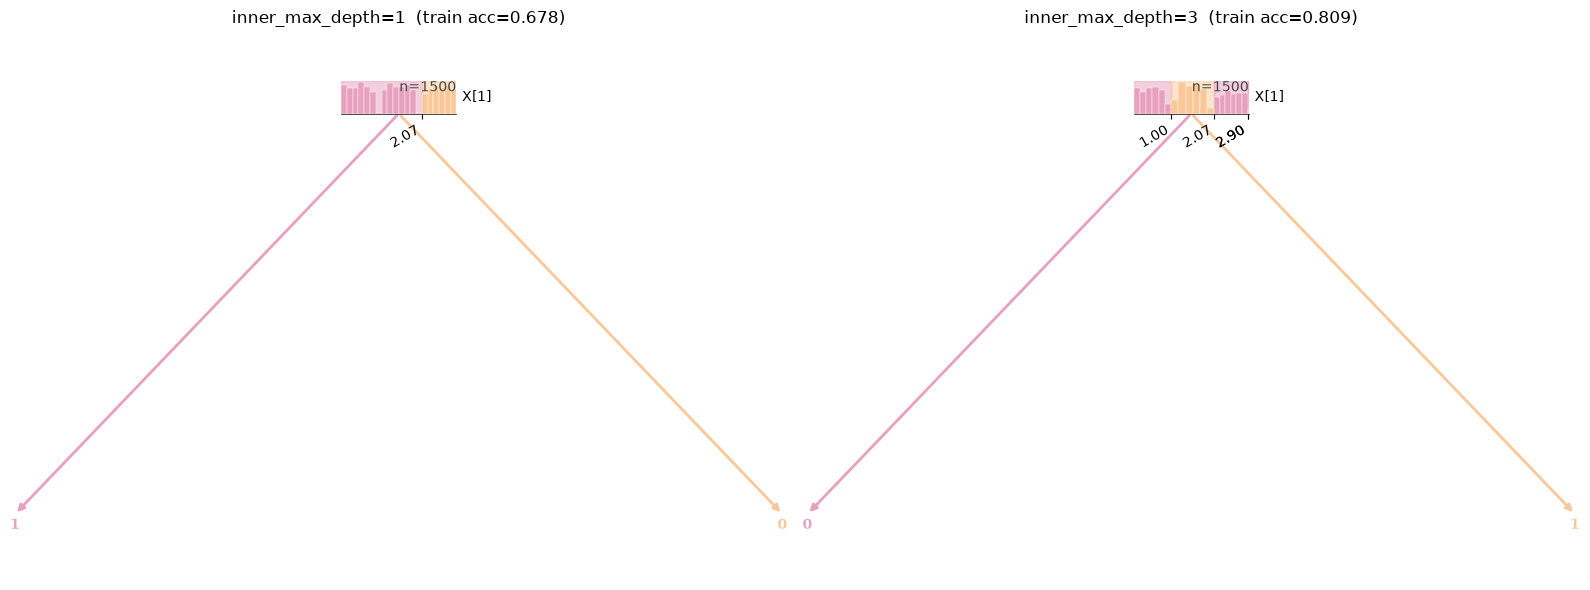

In [1]:
import matplotlib.pyplot as plt
from sgtlearn import SGTClassifier, plot_tree, make_plus

X, y = make_plus(n_samples=1500, grid=3, margin=0.07, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, depth in zip(axes, (1, 3)):
    m = SGTClassifier(max_depth=1, inner_max_depth=depth, random_state=42).fit(X, y)
    plot_tree(m, X=X, ax=ax)
    ax.set_title(f"inner_max_depth={depth}  (train acc={m.score(X, y):.3f})")
plt.tight_layout()
plt.show()

## What to notice

With `inner_max_depth=1` the single root node can only split the feature once — it cannot separate the plus sign's centre band from the two outer bands. With `inner_max_depth=3` the same single node carves the feature into multiple bins and routes the middle band differently, so one node already captures the non-monotone pattern. Compare the training accuracies printed in the titles.

In [2]:
# inner_max_leaf_nodes caps the number of bins directly.
for leaves in (2, 4, 8):
    m = SGTClassifier(
        max_depth=1, inner_max_depth=4, inner_max_leaf_nodes=leaves, random_state=42
    ).fit(X, y)
    print(f"inner_max_leaf_nodes={leaves}: train acc={m.score(X, y):.3f}")

inner_max_leaf_nodes=2: train acc=0.678
inner_max_leaf_nodes=4: train acc=0.808
inner_max_leaf_nodes=8: train acc=0.811


More bins let one node express a more detailed shape, up to the point where the pattern is captured. See [SGT_K multi-way branching](sgt-k.ipynb) for the complementary *outer* branching knob, and [Structure vs. accuracy](structure-and-accuracy.ipynb) for how these interact with generalization.